## CNN Model

- We will be seeing both traditional (FNN) and CNN implementation on MNIST dataset.

### Loading MNIST dataset

In [4]:
from sklearn.datasets import load_digits


In [5]:
data = load_digits()
data.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [12]:
X = data['data']
y = data['target']

In [13]:
X , y

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)))

- Now lets view one image data point

In [14]:
import matplotlib.pyplot as plt

In [15]:
example_view_data = X[0]
example_view_data.shape

(64,)

In [16]:
example_view_data

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [17]:
import numpy as np

In [21]:
reshape_example_digit = example_view_data.reshape(8, 8)
reshape_example_digit.shape

(8, 8)

In [22]:
reshape_example_digit

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

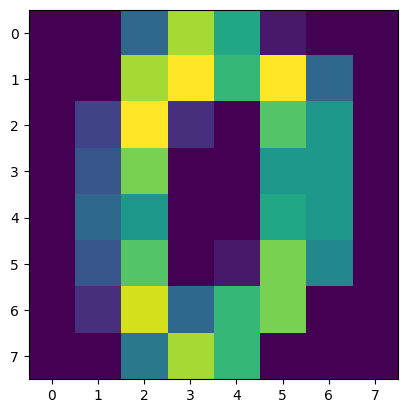

In [23]:
plt.imshow(reshape_example_digit)

- In scikit learn dataset 'load_digits', it has less data points (pixels). So we will be using OpenML's MNIST dataset because it has large amount of data points (pixels) init.

In [35]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist['data'], mnist['target']


In [36]:
X = X.values 
y = y.values

In [37]:
X.shape

(70000, 784)

In [38]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

- Lets view 0 index image

In [39]:
example_view_data = X[0]
example_view_data.shape

(784,)

In [40]:
reshape_example_digit = example_view_data.reshape(28, 28)
reshape_example_digit.shape

(28, 28)

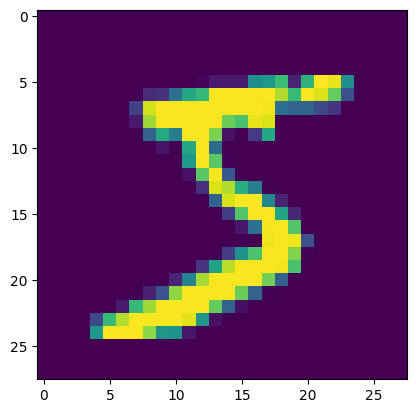

In [41]:
plt.imshow(reshape_example_digit)

In [42]:
y[0]

'5'

In [45]:
y = np.array(y, dtype=int)
y[0]

np.int64(5)

## Traditional FNN Model

In [46]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [48]:
# Lets convert our data into torch tensors
import torch

In [49]:
X_tensors = torch.tensor(X, dtype=torch.float)
y_tensors = torch.tensor(y, dtype=torch.long)

In [50]:
X_tensors.shape, y_tensors.shape

(torch.Size([70000, 784]), torch.Size([70000]))

In [51]:
# train test split
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_tensors, y_tensors, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([56000, 784]),
 torch.Size([14000, 784]),
 torch.Size([56000]),
 torch.Size([14000]))

In [53]:
import torch.nn as nn

In [56]:
# FNN Model

class FNNModel(nn.Module):
    def __init__(self, input_dim=784, hidden_1=394, hidden_2=196, hidden_3=49, output_dim=10):
        super(FNNModel, self).__init__() 

        # layers define 
        self.fc1 = nn.Linear(input_dim, hidden_1) # input layer

        # hidden state - start
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu1 = nn.ReLU()

        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.relu2 = nn.ReLU()
        # hidden state - end

        self.fc4 = nn.Linear(hidden_3, output_dim) # output layer
        self.softmax = nn.Softmax()

    def forward(self, x):
        x = self.fc1(x)

        x = self.fc2(x)
        x = self.relu1(x)
        x = self.fc3(x)
        x = self.relu2(x)

        x = self.fc4(x)
        x = self.softmax(x)


        return x

        

In [57]:
fnn_model = FNNModel()
fnn_model


FNNModel(
  (fc1): Linear(in_features=784, out_features=394, bias=True)
  (fc2): Linear(in_features=394, out_features=196, bias=True)
  (relu1): ReLU()
  (fc3): Linear(in_features=196, out_features=49, bias=True)
  (relu2): ReLU()
  (fc4): Linear(in_features=49, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)

In [60]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fnn_model.parameters(), lr=0.001)

In [61]:
epoches = 101 

for epoch in range(epoches):
    fnn_model.train()

    out = fnn_model(X_train)
    loss = loss_function(out, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%10==0:
        print("Epoch: ", epoch, " | Loss: ", loss.item())


/home/aishwarya/Downloads/Notes/PyTorch_Notes/Notebooks/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch:  0  | Loss:  2.3432857990264893
Epoch:  10  | Loss:  1.9618386030197144
Epoch:  20  | Loss:  1.914182424545288
Epoch:  30  | Loss:  1.89999520778656
Epoch:  40  | Loss:  1.8922247886657715
Epoch:  50  | Loss:  1.8860834836959839
Epoch:  60  | Loss:  1.8816980123519897
Epoch:  70  | Loss:  1.849768042564392
Epoch:  80  | Loss:  1.7971197366714478
Epoch:  90  | Loss:  1.7889587879180908
Epoch:  100  | Loss:  1.7819870710372925


In [62]:
from sklearn.metrics import accuracy_score

In [64]:
fnn_model.eval()
with torch.no_grad():
    y_pred = fnn_model(X_test).argmax(dim=1)
accuracy_score(y_pred=y_pred, y_true=y_test)

/home/aishwarya/Downloads/Notes/PyTorch_Notes/Notebooks/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0.6600714285714285

# CNN Model

In [68]:
X_tensors.shape, y_tensors.shape

(torch.Size([70000, 784]), torch.Size([70000]))

In [ ]:
X_